# Purpose

Map Florida counties and visualize the clustering segments geographically.

This notebook joins:
- A county shapefile (county boundary polygons)
- My processed dataset with fips + cluster

Output:
- A Florida county map colored by cluster
- Saved to visuals/

# Imports

In [1]:
import pandas as pd
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt

# Load shapefiles

In [2]:
counties = gpd.read_file("../data/raw/shapefiles/tl_2023_us_county.shp")

In [3]:
counties.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,31,039,00835841,31039,0500000US31039,Cuming,Cuming County,06,H1,G4020,None,None,None,A,1477563029,10772508,+41.9158651,-096.7885168,"POLYGON ((-96.55516 41.91587, -96.55515 41.914..."
1,53,069,01513275,53069,0500000US53069,Wahkiakum,Wahkiakum County,06,H1,G4020,None,None,None,A,680980771,61564427,+46.2946377,-123.4244583,"POLYGON ((-123.72755 46.2645, -123.72756 46.26..."
2,35,011,00933054,35011,0500000US35011,De Baca,De Baca County,06,H1,G4020,None,None,None,A,6016818946,29090018,+34.3592729,-104.3686961,"POLYGON ((-104.89337 34.08894, -104.89337 34.0..."
3,31,109,00835876,31109,0500000US31109,Lancaster,Lancaster County,06,H1,G4020,339,30700,None,A,2169269688,22850324,+40.7835474,-096.6886584,"POLYGON ((-96.68493 40.5233, -96.69219 40.5231..."
4,31,129,00835886,31129,0500000US31129,Nuckolls,Nuckolls County,06,H1,G4020,None,None,None,A,1489645187,1718484,+40.1764918,-098.0468422,"POLYGON ((-98.2737 40.1184, -98.27374 40.1224,..."


# Filter to Florida counties

In [4]:
fl_counties = counties[counties["STATEFP"] == "12"]

In [5]:
fl_counties.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
71,12,053,00295751,12053,0500000US12053,Hernando,Hernando County,06,H1,G4020,None,45300,45294,A,1224975155,627920761,+28.5559951,-082.5259685,"POLYGON ((-82.25329 28.47849, -82.25329 28.478..."
72,12,129,00306912,12129,0500000US12129,Wakulla,Wakulla County,06,H1,G4020,533,45220,None,A,1570615734,804111188,+30.0913354,-084.3591114,"POLYGON ((-84.1608 29.92127, -84.16104 29.9153..."
73,12,131,00295727,12131,0500000US12131,Walton,Walton County,06,H1,G4020,None,18880,None,A,2689179222,961275980,+30.5712465,-086.1627980,"POLYGON ((-86.39203 30.75066, -86.39185 30.753..."
78,12,127,00306921,12127,0500000US12127,Volusia,Volusia County,06,H1,G4020,422,19660,None,A,2851876987,858119062,+29.0577690,-081.1617920,"POLYGON ((-80.8993 28.79097, -80.89956 28.7909..."
194,12,051,00307626,12051,0500000US12051,Hendry,Hendry County,06,H1,G4020,163,17500,None,A,2993896404,86578552,+26.5399670,-081.1521142,"POLYGON ((-81.56656 26.71338, -81.56653 26.713..."


In [6]:
# Expect 67 counties
fl_counties.shape

(67, 19)

# Create FIPS join key

In [7]:
# Added to prevent warning about temporary slice. Tells pandas to make DF, not a slice.
fl_counties = fl_counties.copy()

In [8]:
fl_counties["fips"] = (fl_counties["STATEFP"] + fl_counties["COUNTYFP"]).astype(int)

In [9]:
# fips check
fl_counties[["STATEFP", "COUNTYFP", "fips", "NAME"]]

,STATEFP,COUNTYFP,fips,NAME
71,12,053,12053,Hernando
72,12,129,12129,Wakulla
73,12,131,12131,Walton
78,12,127,12127,Volusia
194,12,051,12051,Hendry
...,...,...,...,...
2985,12,039,12039,Gadsden
3107,12,045,12045,Gulf
3119,12,073,12073,Leon
3204,12,057,12057,Hillsborough


# Load cluster dataset

In [10]:
# Set data paths
PROJECT_ROOT = Path().resolve().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

In [11]:
df = pd.read_csv(DATA_PROCESSED/ "merged_fl_county_year_clusters.csv")

In [12]:
df.head(25)

,fips,RegionName,year,zhvi_annual,STNAME,CTYNAME,domestic_mig,population,rdomestic_mig,yoy_growth,boom_growth_2020_2022,cooling_delta_2024_vs_2022,yoy_volatility,cluster,cluster_name
0,12001,Alachua County,2020,213860.291033,Florida,Alachua County,1315,279765,NaN,NaN,0.319704,-0.125115,0.064152,0,Stable markets
1,12001,Alachua County,2021,244364.099887,Florida,Alachua County,1142,281710,4.067857,0.142634,0.319704,-0.125115,0.064152,0,Stable markets
2,12001,Alachua County,2022,282232.292655,Florida,Alachua County,1268,285241,4.473050,0.154966,0.319704,-0.125115,0.064152,0,Stable markets
3,12001,Alachua County,2023,295677.948240,Florida,Alachua County,408,288962,1.421100,0.047640,0.319704,-0.125115,0.064152,0,Stable markets
4,12001,Alachua County,2024,304504.265219,Florida,Alachua County,-1141,291782,-3.929442,0.029851,0.319704,-0.125115,0.064152,0,Stable markets
5,12003,Baker County,2020,214588.831681,Florida,Baker County,-141,28122,NaN,NaN,0.369415,-0.153888,0.094209,0,Stable markets
6,12003,Baker County,2021,250077.267178,Florida,Baker County,216,28378,7.646018,0.165379,0.369415,-0.153888,0.094209,0,Stable markets
7,12003,Baker County,2022,293861.137166,Florida,Baker County,-657,27781,-23.397853,0.175081,0.369415,-0.153888,0.094209,0,Stable markets
8,12003,Baker County,2023,292472.265114,Florida,Baker County,673,28542,23.897875,-0.004726,0.369415,-0.153888,0.094209,0,Stable markets
9,12003,Baker County,2024,298670.668188,Florida,Baker County,709,29325,24.504467,0.021193,0.369415,-0.153888,0.094209,0,Stable markets


# Reduce to one row per county (and get only required columns)

In [13]:
clusters = df[["fips", "cluster", "cluster_name"]].drop_duplicates()

In [14]:
clusters.head()

,fips,cluster,cluster_name
0,12001,0,Stable markets
5,12003,0,Stable markets
10,12005,2,Balanced growth markets
15,12007,0,Stable markets
20,12009,2,Balanced growth markets


# Merge clusters with county geometry

In [15]:
# Left merge to fl_counties df
map_df = fl_counties.merge(clusters, on="fips", how="left")

In [16]:
map_df[["NAME", "cluster", "cluster_name"]].head()

,NAME,cluster,cluster_name
0,Hernando,1,Migration boom markets
1,Wakulla,0,Stable markets
2,Walton,1,Migration boom markets
3,Volusia,2,Balanced growth markets
4,Hendry,2,Balanced growth markets


In [17]:
# Sanity check. Expect 0
map_df["cluster"].isna().sum()

np.int64(0)

# Create Florida cluster map

In [18]:
# Create cluster labels for map legend
cluster_labels = {0: "0: Stable markets",1: "1: Migration boom markets",2: "2: Balanced growth markets"}

In [19]:
# create a label column for plotting/legend
map_df["cluster_label"] = map_df["cluster"].map(cluster_labels)

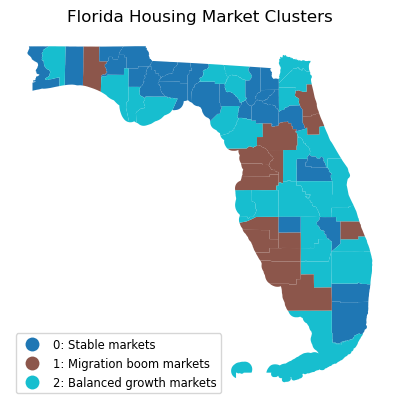

In [20]:
# create map with legend modified to not overlap counties
ax = map_df.plot(column="cluster_label",legend=True,legend_kwds={"loc": "lower left", "fontsize": "small"})

# title
ax.set_title("Florida Housing Market Clusters")

# remove axis (maps look cleaner)
ax.set_axis_off()

# export image to visuals folder
plt.savefig("../visuals/florida_housing_clusters_map.png", bbox_inches="tight")

plt.show()

# Prepare migration values

In [21]:
# average migration rate per county during 2021–2024
migration_avg = (df[df["year"].between(2021, 2024)].groupby("fips")["rdomestic_mig"].mean().reset_index())

In [22]:
migration_avg.head()

,fips,rdomestic_mig
0,12001,1.508141
1,12003,8.162627
2,12005,27.610062
3,12007,0.795386
4,12009,21.448371


# Merge migration values onto map

In [23]:
map_mig = map_df.merge(migration_avg, on="fips", how="left")

In [24]:
map_mig.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,...,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,fips,cluster,cluster_name,cluster_label,rdomestic_mig
0,12,053,00295751,12053,0500000US12053,Hernando,Hernando County,06,H1,G4020,...,1224975155,627920761,+28.5559951,-082.5259685,"POLYGON ((-82.25329 28.47849, -82.25329 28.478...",12053,1,Migration boom markets,1: Migration boom markets,32.697946
1,12,129,00306912,12129,0500000US12129,Wakulla,Wakulla County,06,H1,G4020,...,1570615734,804111188,+30.0913354,-084.3591114,"POLYGON ((-84.1608 29.92127, -84.16104 29.9153...",12129,0,Stable markets,0: Stable markets,23.566601
2,12,131,00295727,12131,0500000US12131,Walton,Walton County,06,H1,G4020,...,2689179222,961275980,+30.5712465,-086.1627980,"POLYGON ((-86.39203 30.75066, -86.39185 30.753...",12131,1,Migration boom markets,1: Migration boom markets,38.667413
3,12,127,00306921,12127,0500000US12127,Volusia,Volusia County,06,H1,G4020,...,2851876987,858119062,+29.0577690,-081.1617920,"POLYGON ((-80.8993 28.79097, -80.89956 28.7909...",12127,2,Balanced growth markets,2: Balanced growth markets,22.513934
4,12,051,00307626,12051,0500000US12051,Hendry,Hendry County,06,H1,G4020,...,2993896404,86578552,+26.5399670,-081.1521142,"POLYGON ((-81.56656 26.71338, -81.56653 26.713...",12051,2,Balanced growth markets,2: Balanced growth markets,19.081570


# Plot migration map

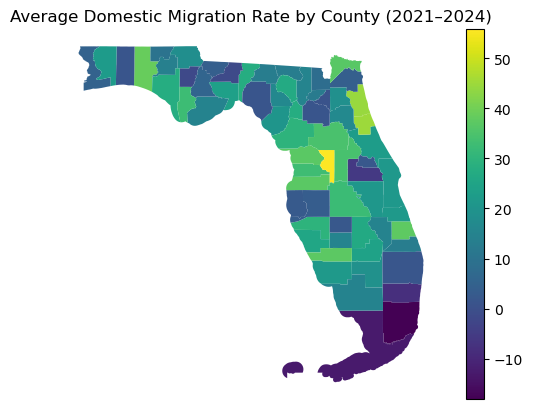

In [25]:
ax = map_mig.plot(column="rdomestic_mig",legend=True)

ax.set_title("Average Domestic Migration Rate by County (2021–2024)")
ax.set_axis_off()

plt.savefig("../visuals/florida_migration_rate_map.png", bbox_inches="tight")

plt.show()

# Prepare boom growth values (one row per county)

In [26]:
boom = df[["fips", "boom_growth_2020_2022"]].drop_duplicates()

In [27]:
boom.head()

,fips,boom_growth_2020_2022
0,12001,0.319704
5,12003,0.369415
10,12005,0.426789
15,12007,0.428973
20,12009,0.455545


# Merge boom growth onto map geometry

In [29]:
map_boom = map_df.merge(boom, on="fips", how="left")

In [31]:
# Sanity check
map_boom["boom_growth_2020_2022"].isna().sum()

np.int64(0)

# Map boom growth (2020–2022)

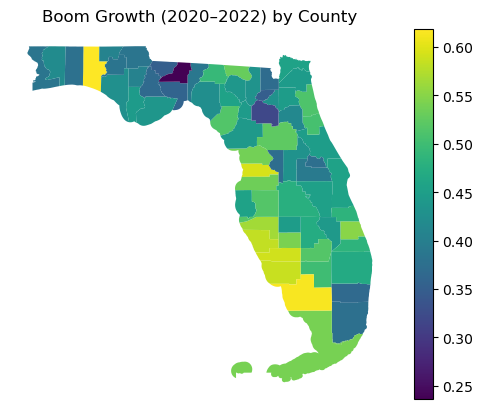

In [32]:
ax = map_boom.plot(column="boom_growth_2020_2022", legend=True)

ax.set_title("Boom Growth (2020–2022) by County")
ax.set_axis_off()

plt.savefig("../visuals/florida_boom_growth_map.png", bbox_inches="tight")
plt.show()